# 02 — Data Preprocessing Pipeline

**Mục tiêu:** Xây dựng pipeline tiền xử lý dữ liệu dựa trên kết luận từ EDA (`01_eda.ipynb`).

**Các bước:**
1. Load & chia tập (Train / Val / Test) — **trước** khi fit bất kỳ thứ gì
2. Định nghĩa các Custom Transformers
3. Xây dựng `sklearn Pipeline`
4. Fit pipeline trên Train, transform toàn bộ 3 tập
5. Lưu dữ liệu đã xử lý + pipeline ra file


## 0. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import joblib

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, LabelEncoder

# ── Paths ──
ROOT        = Path("..") 
RAW_PATH    = ROOT / "data" / "raw" / "Crop_recommendation.csv"
PROC_DIR    = ROOT / "data" / "processed"
MODEL_DIR   = ROOT / "saved_models"

PROC_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

REQUIRED_COLUMNS = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
TARGET = "label"

RANDOM_STATE = 42
print("Setup OK")


Setup OK


## 1. Load Data & Chia Tập

> **Chia tập TRƯỚC** — không được nhìn vào Val/Test khi fit pipeline.

In [2]:
df = pd.read_csv(RAW_PATH)
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
X = df[REQUIRED_COLUMNS].copy()
y = df[TARGET].copy()

# Chia 80% train, 10% val, 10% test — stratified để giữ cân bằng 22 class
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print(f"Train : {X_train.shape}  ({len(X_train)/len(X):.0%})")
print(f"Val   : {X_val.shape}   ({len(X_val)/len(X):.0%})")
print(f"Test  : {X_test.shape}  ({len(X_test)/len(X):.0%})")
print()
print("Label distribution (train):")
print(y_train.value_counts().sort_index())


Train : (1760, 7)  (80%)
Val   : (220, 7)   (10%)
Test  : (220, 7)  (10%)

Label distribution (train):
label
apple          80
banana         80
blackgram      80
chickpea       80
coconut        80
coffee         80
cotton         80
grapes         80
jute           80
kidneybeans    80
lentil         80
maize          80
mango          80
mothbeans      80
mungbean       80
muskmelon      80
orange         80
papaya         80
pigeonpeas     80
pomegranate    80
rice           80
watermelon     80
Name: count, dtype: int64


In [4]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)   # fit chỉ trên train
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

print("Classes:", list(le.classes_))
print("Encoded sample:", y_train_enc[:10])


Classes: ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']
Encoded sample: [16  7  9 13 16  6  1 16  7 10]


## 2. Định Nghĩa Custom Transformers

### 2.1 ColumnSchemaEnforcer
Đảm bảo input có đúng các cột yêu cầu.

In [5]:
class ColumnSchemaEnforcer(BaseEstimator, TransformerMixin):
    """Kiểm tra và sắp xếp lại các cột theo đúng schema yêu cầu."""
    def __init__(self, required_columns, drop_extra=True):
        self.required_columns = list(required_columns)
        self.drop_extra = drop_extra

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        missing = [c for c in self.required_columns if c not in X.columns]
        if missing:
            raise ValueError(f"Missing required columns: {missing}")
        if self.drop_extra:
            X = X[self.required_columns]
        return X


### 2.2 TypeCaster
Ép kiểu dữ liệu đúng cho từng cột.

In [6]:
class TypeCaster(BaseEstimator, TransformerMixin):
    """Ép kiểu: N, P, K -> int; temperature, humidity, ph, rainfall -> float."""
    def __init__(self, int_cols=None, float_cols=None):
        self.int_cols   = int_cols   or []
        self.float_cols = float_cols or []

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.int_cols:
            if col in X.columns:
                X[col] = X[col].astype(float).round().astype(int)
        for col in self.float_cols:
            if col in X.columns:
                X[col] = X[col].astype(float)
        return X


### 2.3 QuantileClipper
Cắt outlier tại [q_low, q_high] quantile **tính trên Train**.

In [7]:
class QuantileClipper(BaseEstimator, TransformerMixin):
    """
    Clip giá trị về [lower_quantile, upper_quantile].
    Thống kê quantile được fit trên Train — không có data leakage.
    """
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            self.lower_ = X.quantile(self.lower)
            self.upper_ = X.quantile(self.upper)
        else:
            arr = np.array(X)
            self.lower_ = np.percentile(arr, self.lower * 100, axis=0)
            self.upper_ = np.percentile(arr, self.upper * 100, axis=0)
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            return X.clip(lower=self.lower_, upper=self.upper_, axis=1)
        else:
            arr = np.array(X, dtype=float)
            return np.clip(arr, self.lower_, self.upper_)


### 2.4 FeatureEngineer
Thêm 6 features mới từ kết luận EDA. **Stateless** — không có tham số được fit từ dữ liệu.

In [8]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Tạo 6 derived features từ kết luận EDA:
    - total_npk    = N + P + K          (tổng chất dinh dưỡng)
    - ratio_n_p    = N / (P + eps)      (tỷ lệ N:P)
    - ratio_n_k    = N / (K + eps)      (tỷ lệ N:K)
    - ratio_p_k    = P / (K + eps)      (tỷ lệ P:K — phân biệt nhóm đậu đỗ)
    - temp_humidity = temperature * humidity / 100  (chỉ số khí hậu kết hợp)
    - log_rainfall = log(1 + rainfall)  (giảm độ lệch phân phối)

    ⚡ Không có tham số được học từ data → KHÔNG gây data leakage.
    """
    def __init__(self, eps=1e-6):
        self.eps = eps

    def fit(self, X, y=None):
        return self   # stateless

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            out = X.copy()
        else:
            out = pd.DataFrame(X, columns=REQUIRED_COLUMNS)

        eps = self.eps
        out["total_npk"]     = out["N"] + out["P"] + out["K"]
        out["ratio_n_p"]     = out["N"] / (out["P"] + eps)
        out["ratio_n_k"]     = out["N"] / (out["K"] + eps)
        out["ratio_p_k"]     = out["P"] / (out["K"] + eps)
        out["temp_humidity"] = out["temperature"] * out["humidity"] / 100.0
        out["log_rainfall"]  = np.log1p(out["rainfall"])
        return out


## 3. Xây Dựng Pipeline

In [9]:
preprocessor = Pipeline(steps=[
    ("schema",    ColumnSchemaEnforcer(REQUIRED_COLUMNS, drop_extra=True)),
    ("types",     TypeCaster(
                      int_cols=["N", "P", "K"],
                      float_cols=["temperature", "humidity", "ph", "rainfall"]
                  )),
    ("imputer",   SimpleImputer(strategy="median")),   # phòng thủ — 0 missing nhưng cần pipeline ổn định
    ("engineer",  FeatureEngineer(eps=1e-6)),
    ("clipper",   QuantileClipper(lower=0.01, upper=0.99)),
    ("scaler",    RobustScaler()),                     # RobustScaler: dùng median+IQR, chịu outlier
])

print("Pipeline:")
for name, step in preprocessor.steps:
    print(f"  [{name}] {step.__class__.__name__}")


Pipeline:
  [schema] ColumnSchemaEnforcer
  [types] TypeCaster
  [imputer] SimpleImputer
  [engineer] FeatureEngineer
  [clipper] QuantileClipper
  [scaler] RobustScaler


## 4. Fit & Transform

> `fit_transform` chỉ chạy trên **Train**. Val và Test chỉ `transform`.

In [10]:
# ⚠️ Fit ONLY on train — tránh data leakage
X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep   = preprocessor.transform(X_val)
X_test_prep  = preprocessor.transform(X_test)

print(f"X_train_prep shape: {X_train_prep.shape}")
print(f"X_val_prep   shape: {X_val_prep.shape}")
print(f"X_test_prep  shape: {X_test_prep.shape}")


X_train_prep shape: (1760, 13)
X_val_prep   shape: (220, 13)
X_test_prep  shape: (220, 13)


### 4.1 Kiểm Tra Chất Lượng Sau Preprocessing

In [11]:
nan_count = np.isnan(X_train_prep).sum()
inf_count = np.isinf(X_train_prep).sum()
print(f"NaN count  : {nan_count}")
print(f"Inf count  : {inf_count}")
print()

FEATURE_NAMES = REQUIRED_COLUMNS + [
    "total_npk", "ratio_n_p", "ratio_n_k",
    "ratio_p_k", "temp_humidity", "log_rainfall"
]
train_df = pd.DataFrame(X_train_prep, columns=FEATURE_NAMES)
print("Thống kê Train sau preprocessing:")
train_df.describe().T.round(4)


NaN count  : 0
Inf count  : 0

Thống kê Train sau preprocessing:


,count,mean,std,min,25%,50%,75%,max
N,1760.0,0.2107,0.5738,-0.5781,-0.2500,0.0,0.7500,1.4098
P,1760.0,0.0584,0.8225,-1.1250,-0.5750,0.0,0.4250,2.3000
K,1760.0,0.5570,1.7473,-0.8417,-0.4138,0.0,0.5862,5.9310
temperature,1760.0,0.0158,0.8672,-2.3756,-0.4744,0.0,0.5256,2.7273
humidity,1760.0,-0.3075,0.7487,-2.1984,-0.6848,0.0,0.3152,0.5522
ph,1760.0,0.0433,0.7738,-1.8884,-0.4873,-0.0,0.5127,2.3851
rainfall,1760.0,0.1448,0.9237,-1.2347,-0.5119,0.0,0.4881,2.9722
total_npk,1760.0,0.0721,0.9514,-1.3571,-0.6190,0.0,0.3810,2.7381
ratio_n_p,1760.0,0.4569,1.3481,-0.5414,-0.3281,-0.0,0.6719,7.6661
ratio_n_k,1760.0,0.1584,0.9032,-0.8654,-0.5220,-0.0,0.4780,3.5550


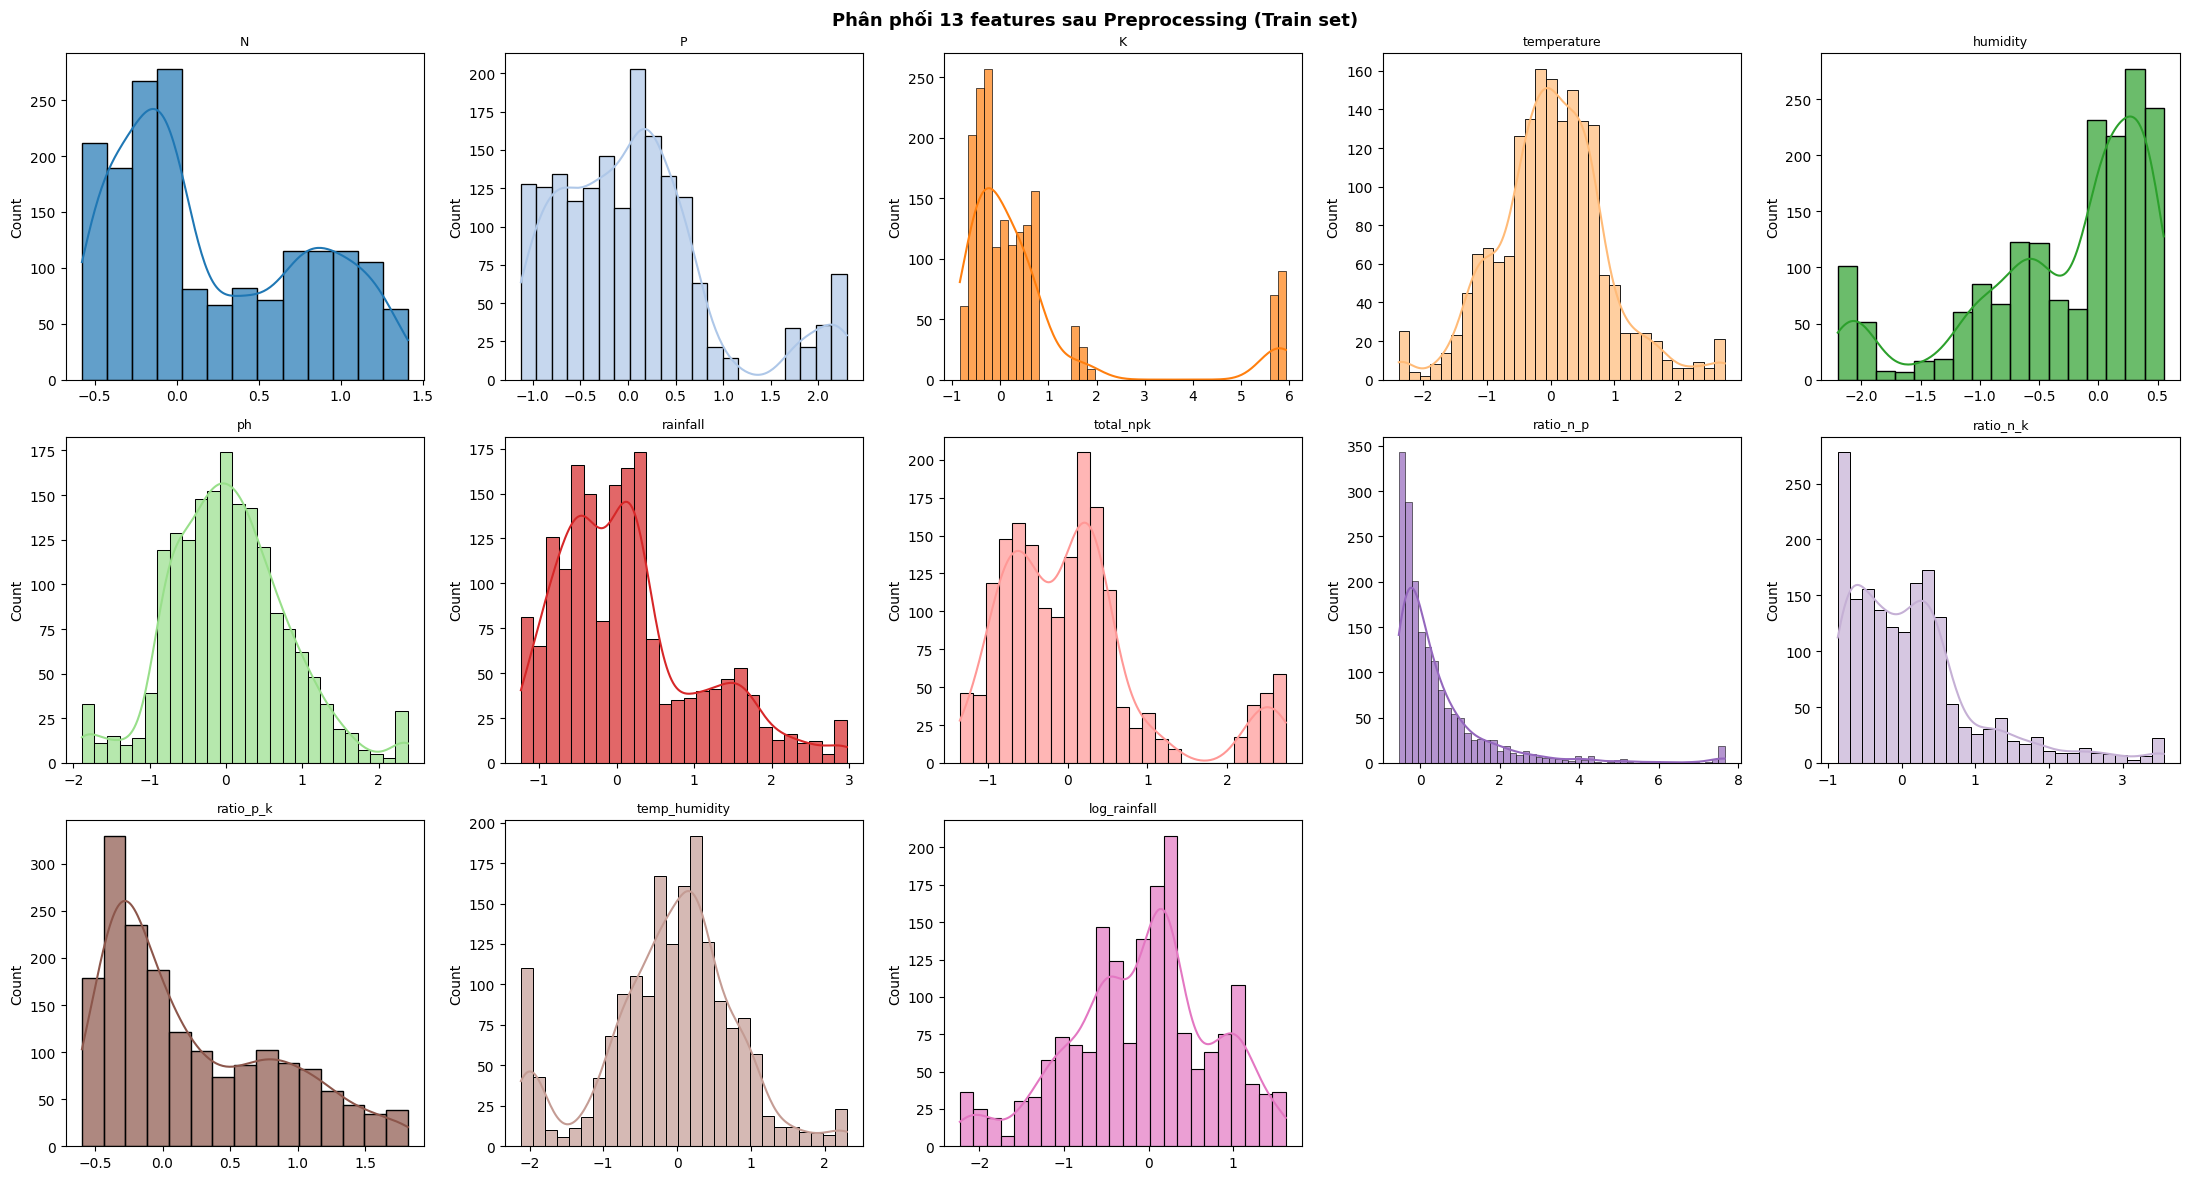


📌 Nhận xét: Các features đã được scale về range tương đương.
  RobustScaler → median ≈ 0, phần lớn giá trị nằm trong [-2, 2].
  log_rainfall đã giảm độ lệch so với rainfall gốc.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 5, figsize=(22, 12))
axes = axes.flatten()
colors = plt.cm.tab20.colors

for i, col in enumerate(FEATURE_NAMES):
    sns.histplot(train_df[col], kde=True, ax=axes[i], color=colors[i % 20], alpha=0.7)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

for j in range(len(FEATURE_NAMES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Phân phối 13 features sau Preprocessing (Train set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("\n📌 Nhận xét: Các features đã được scale về range tương đương.")
print("  RobustScaler → median ≈ 0, phần lớn giá trị nằm trong [-2, 2].")
print("  log_rainfall đã giảm độ lệch so với rainfall gốc.")


## 5. Lưu Dữ Liệu Đã Xử Lý & Pipeline

In [13]:
# Tạo DataFrames với nhãn
def make_df(X_arr, y_arr, feature_names, label_names):
    df_out = pd.DataFrame(X_arr, columns=feature_names)
    df_out[TARGET] = y_arr            # encoded label (int)
    df_out["label_name"] = label_names.values  # tên gốc
    return df_out

train_out = make_df(X_train_prep, y_train_enc, FEATURE_NAMES, y_train.reset_index(drop=True))
val_out   = make_df(X_val_prep,   y_val_enc,   FEATURE_NAMES, y_val.reset_index(drop=True))
test_out  = make_df(X_test_prep,  y_test_enc,  FEATURE_NAMES, y_test.reset_index(drop=True))

# Lưu CSV
train_out.to_csv(PROC_DIR / "train.csv", index=False)
val_out.to_csv(PROC_DIR / "val.csv",     index=False)
test_out.to_csv(PROC_DIR / "test.csv",   index=False)
print(f"✅ Saved CSVs → {PROC_DIR}/")

# Lưu pipeline (preprocessor) và label encoder
joblib.dump(preprocessor, MODEL_DIR / "preprocessor.pkl")
joblib.dump(le,           MODEL_DIR / "label_encoder.pkl")
print(f"✅ Saved preprocessor  → {MODEL_DIR}/preprocessor.pkl")
print(f"✅ Saved label_encoder → {MODEL_DIR}/label_encoder.pkl")


✅ Saved CSVs → ../data/processed/
✅ Saved preprocessor  → ../saved_models/preprocessor.pkl
✅ Saved label_encoder → ../saved_models/label_encoder.pkl


In [14]:
# Kiểm tra file đã lưu
print("=== Files saved ===")
for f in sorted(PROC_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:20s}  {size_kb:8.1f} KB")
for f in sorted(MODEL_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:20s}  {size_kb:8.1f} KB")


=== Files saved ===
  .gitkeep                   0.0 KB
  test.csv                  52.1 KB
  test_preprocessed.csv      50.3 KB
  train.csv                415.3 KB
  train_preprocessed.csv     401.4 KB
  val.csv                   52.0 KB
  val_preprocessed.csv      50.2 KB
  .gitkeep                   0.0 KB
  label_encoder.pkl          0.7 KB
  preprocessor.pkl           4.4 KB


---
## 6. Tóm Tắt Pipeline

| Bước | Transformer | Mục đích | Ghi chú Data Leakage |
|------|-------------|----------|----------------------|
| 1 | `ColumnSchemaEnforcer` | Đảm bảo 7 cột đúng tên/thứ tự | Stateless ✅ |
| 2 | `TypeCaster` | Ép kiểu N,P,K→int; phần còn lại→float | Stateless ✅ |
| 3 | `SimpleImputer(median)` | Điền NaN bằng median | Fit trên Train ✅ |
| 4 | `FeatureEngineer` | Thêm 6 features mới (ratio, interaction, log) | Stateless ✅ |
| 5 | `QuantileClipper[1%,99%]` | Cắt outlier cực biên | Fit trên Train ✅ |
| 6 | `RobustScaler` | Chuẩn hóa dùng median/IQR | Fit trên Train ✅ |

**Output:** 13 features = 7 gốc + 6 engineered

| Feature mới | Công thức | Lý do từ EDA |
|---|---|---|
| `total_npk` | N + P + K | Pattern tổng NPK đặc trưng cho nhóm cây |
| `ratio_n_p` | N / (P + ε) | Tỷ lệ tương đối quan trọng hơn giá trị tuyệt đối |
| `ratio_n_k` | N / (K + ε) | Phân biệt nhóm N cao vs K cao |
| `ratio_p_k` | P / (K + ε) | Dấu vân tay nhóm đậu đỗ (P,K cao) |
| `temp_humidity` | temp × humidity / 100 | Chỉ số khí hậu kết hợp |
| `log_rainfall` | log(1 + rainfall) | Rainfall lệch phải mạnh → log giảm skewness |

**Tập chia:**
- Train: **1760 mẫu** (80%)
- Val:   **220 mẫu** (10%)
- Test:  **220 mẫu** (10%)
- Stratified → mỗi tập có 22 class × đúng tỷ lệ
